tableu :  
https://public.tableau.com/app/profile/mochamad.rexy.nurulsaputra/viz/Ney1/Dashboard4?publish=yes

# Introduction

```py
'''
===========================================================================================================================================================================

Nama  : Mochamad Rexy Nurulsaputra  
Batch : HCK - 035  

===========================================================================================================================================================================
'''
```

In [22]:
#importing tools that will be used
import pandas as pd                             # for cleaning data
import numpy as np                              # for math
from scipy import stats as sp_stats             # for statistic
import matplotlib.pyplot as plt                 # for graph
import seaborn as sns                           # for graph

# 1. Problem Statement and Dataset Description

## 1.1. Research Topic

Analisis Churn Rate pada Perusahaan Telekomunikasi untuk Strategi Retensi Pelanggan.

## 1.2. Background

Perusahaan telekomunikasi menghadapi tantangan tingginya tingkat churn (pelanggan berhenti berlangganan) sebesar 26,5%. Tingginya churn rate berdampak signifikan terhadap pendapatan perusahaan, mengingat biaya akuisisi pelanggan baru lebih mahal 5-25 kali lipat dibandingkan mempertahankan pelanggan eksisting. Analisis ini bertujuan untuk mengidentifikasi pola dan faktor penyebab churn guna merumuskan strategi retensi yang efektif.

## 1.3. SMART

**Specific**:  
Menurunkan churn rate pelanggan telco dari 26,5% menjadi 20%.

**Measurable**:  
Mengurangi 6,5% churn rate

**Achievable**:   
Melalui implementasi program retensi berbasis analisis data yang mengidentifikasi faktor-faktor kunci penyebab churn.

**Relevant**:  
Meningkatkan profit perusahaan sebesar ±9%
Jika program berhasil mempertahankan pelanggan selama 12 bulan
Mengurangi tekanan pada anggaran marketing untuk akuisisi pelanggan baru

**Time-bound**:   
Mencapai target dalam waktu 6 bulan setelah implementasi program retensi.

## 1.4. Problem Statement

Menurunkan churn rate pelanggan telco dari 26,5% menjadi 20% atau pengurangan 6,5% churn rate yang terjadi, program ini mempunyai target dalam waktu 6 bulan dengan mengimplementasikan program retensi berbasis analisis data yang mengidentifikasi faktor - faktor kunci penyebab churn sehingga dapat:  
1. Meningkatkan profit perusahaan sebesar ±9%,  
2. Mempertahankan pelanggan selama 12 bulan,  
3. Mengurangi tekanan pada anggaran marketing untuk akuisisi,  pelanggan baru,  

## 1.5. Dataset Source

Nama Dataset    : Telco Customer Churn  
Sumber          : IBM GitHub Repository  
URL             : https://github.com/IBM/telco-customer-churn-on-icp4d/blob/master/data/Telco-Customer-Churn.csv   
Lisensi         : Apache License 2.0, January 2004  

## 1.6. Problem Elaboration

Pada data ini penulis akan menggunakan 5w 1h untuk pejabaran masalah, meliputi:  

**Who**  
Pelanggan dengan karakteristik apa saja yang paling tinggi churn ratenya?  
**What**  
Layanan tambahan apa yang paling berpengaruh terhadap keputusan chur?  
**When**  
Pada bulan berlangganan keberapa chur paling banyak terjadi?  
**How**  
Bagaimana hubungan antara jenis kontrak dengan kecenderungan churn?  
**What**  
Apa perbedaan karakteristik numerik antara pelanggan yang churn denga yang tidak churn?  
**Why**  
Apakah perbedaan signifikan dalam rata - rata tenure antara pelanggan dengan kontrak berbeda?  

# 2. Data Loading 

## 2.1. Reading and Showing The Data

In [23]:
# Make variable df to read the data from file .csv 
df = pd.read_csv('P0M1_rexy_nurulsaputraraw.csv')
# Showing the data
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


### Berdasarkan data diatas, penulis akan merubah value yes no menjadi 1 0 atau dapat dikatakan true n false / menjadikan value itu bertype boolean

## 2.2. Melihat type data, dan melihat ada tidaknya nilai yang hilang pada data

In [24]:
# showing data types, missing value, and looking at the name of the column
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


None

### Pada data terdapat 1 type data float, 2 type data int, dan 18 type data string

## 2.3. Melihat apakah ada nilai yang hilang pada tiap - tiap kolom

In [25]:
# show missing value data each column
display(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Pada data ini tidak terdapat nilai yang hilang di setiap kolomnya menurut tabel data disini.

In [26]:
# check data types and missing values
tipe_data = df.dtypes
nilai_hil = df.isnull().sum()
nilai_hil_prcnt = (nilai_hil / len(df)) * 100

# conclusion about the data
simpul_data = pd.DataFrame({
    'Data Type': tipe_data,
    'Missing Values': nilai_hil,
    'Missing %': nilai_hil_prcnt,
    'Unique Values': df.nunique()
})

display(simpul_data)

,Data Type,Missing Values,Missing %,Unique Values
customerID,object,0,0.0,7043
gender,object,0,0.0,2
SeniorCitizen,int64,0,0.0,2
Partner,object,0,0.0,2
Dependents,object,0,0.0,2
tenure,int64,0,0.0,73
PhoneService,object,0,0.0,2
MultipleLines,object,0,0.0,3
InternetService,object,0,0.0,3
OnlineSecurity,object,0,0.0,3


Ada perubahan yang harus dilakukan terhadap data, dikarena kita akan melakukan uji statistik pada data sehingga nilai data yang bernilai "yes" akan dirubah menjadi 1, dan nilai data yang bernilai "no" akan dirubah menjadi 0, serta mengganti type data menjadi boolean / int

# 3. Data Cleaning

In [27]:
# Make variable df to read the data from file .csv 
df = pd.read_csv('P0M1_rexy_nurulsaputraraw.csv')

## 3.1. Membuat salinan dataframe berupa variable df_clean

In [28]:
# make variable df_clean to store the copy of raw data 
df_clean = df.copy()

## 3.2. Mengubah nilai dan type data kolom

In [29]:
# fixing TotalCharges column
# Remove whitespace, replace empty strings with '0', convert to float
df_clean['TotalCharges'] = df_clean['TotalCharges'].str.strip().replace('', '0').astype(float)

# changing datatypes MonthlyCharges to float
df_clean['MonthlyCharges'] = df_clean['MonthlyCharges'].astype(float)


# changing datatypes Churn to int and,
# replacing the value from 'yes','no' to 1,2
df_clean['Churn'] = df_clean['Churn'].replace({'Yes': 1, 'No': 0}).astype(int)

# making grup 1 for column   
var_grup1 = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
# changing datatypes grup1 columns to int and
# replacing the value from 'yes','no' to 1,2
for col in var_grup1:
    df_clean[col] = df_clean[col].replace({'Yes': 1, 'No': 0}).astype(int)

# making grup 2 for column  
var_grup2 = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']
# changing datatypes grup2 columns to int and,
# replacing the value from 'yes','no' to 1,2 and,
# changin No internet service, and No phone service to 0
for col in var_grup2:
    df_clean[col] = df_clean[col].replace({'No internet service': 0,'No phone service': 0,'Yes': 1,'No': 0}).astype(int)
print("="*50)
print("\n" + " "*18 + "DATA CLEANED!\n")
print("="*50)


                  DATA CLEANED!



C:\Users\Biney\AppData\Local\Temp\ipykernel_164412\3414696703.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['Churn'] = df_clean['Churn'].replace({'Yes': 1, 'No': 0}).astype(int)
C:\Users\Biney\AppData\Local\Temp\ipykernel_164412\3414696703.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean[col] = df_clean[col].replace({'Yes': 1, 'No': 0}).astype(int)
C:\Users\Biney\AppData\Local\Temp\ipykernel_164412\3414696703.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a

## 3.3. Mengecek dan Membandingkan data sesudah dan sebelum di cleaning

### Memperlihatkan data sebelum dan sesudah di cleaning

In [30]:
# display data before cleaning
display(df)

# display data after cleaning
display(df_clean)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1,0,1,0,0,DSL,0,...,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,0,0,34,1,0,DSL,1,...,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,0,0,2,1,0,DSL,1,...,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,0,0,45,0,0,DSL,1,...,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,0,0,2,1,0,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,1,1,24,1,1,DSL,1,...,1,1,1,1,One year,1,Mailed check,84.80,1990.50,0
7039,2234-XADUH,Female,0,1,1,72,1,1,Fiber optic,0,...,1,0,1,1,One year,1,Credit card (automatic),103.20,7362.90,0
7040,4801-JZAZL,Female,0,1,1,11,0,0,DSL,1,...,0,0,0,0,Month-to-month,1,Electronic check,29.60,346.45,0
7041,8361-LTMKD,Male,1,1,0,4,1,1,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Mailed check,74.40,306.60,1


## 3.4. Kesimpulan data

### Menampilkan tabel kesimpulan cleaning data

In [31]:
# check data types and missing values
tipe_data_c = df_clean.dtypes
nilai_hil_c = df_clean.isnull().sum()
nilai_hil_prcnt_c = (nilai_hil_c/ len(df_clean)) * 100

# conclusion about the clean
simpul_data_c = pd.DataFrame({
    'Data Type': tipe_data_c,
    'Missing Values': nilai_hil_c,
    'Missing %': nilai_hil_prcnt_c,
    'Unique Values': df.nunique()
})

display(simpul_data_c)

,Data Type,Missing Values,Missing %,Unique Values
customerID,object,0,0.0,7043
gender,object,0,0.0,2
SeniorCitizen,int64,0,0.0,2
Partner,int32,0,0.0,2
Dependents,int32,0,0.0,2
tenure,int64,0,0.0,73
PhoneService,int32,0,0.0,2
MultipleLines,int32,0,0.0,3
InternetService,object,0,0.0,3
OnlineSecurity,int32,0,0.0,3


## 3.5. Menyimpan data clean untuk visualisasi

In [32]:
# saving to csv
df_clean.to_csv('P0M1_rexy_nurulsaputra.csv',index=False)

# 4. Exploration and Analysis

## 4.1. Pelanggan dengan karakteristik apa saja yang paling tinggi churn ratenya?  

In [ ]:
# membuat var demographic_churn
demographic_churn = df_clean.groupby(['gender', 'SeniorCitizen']).agg(total_customers=('customerID', 'count'),churn_count=('Churn', 'sum')).reset_index()
demographic_churn['churn_rate'] = demographic_churn['churn_count'] / demographic_churn['total_customers']
display(demographic_churn)

,gender,SeniorCitizen,total_customers,churn_count,churn_rate
0,Female,0,2920,699,0.239384
1,Female,1,568,240,0.422535
2,Male,0,2981,694,0.232808
3,Male,1,574,236,0.411150


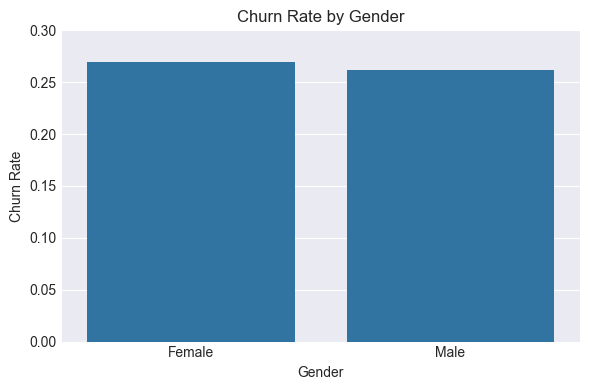

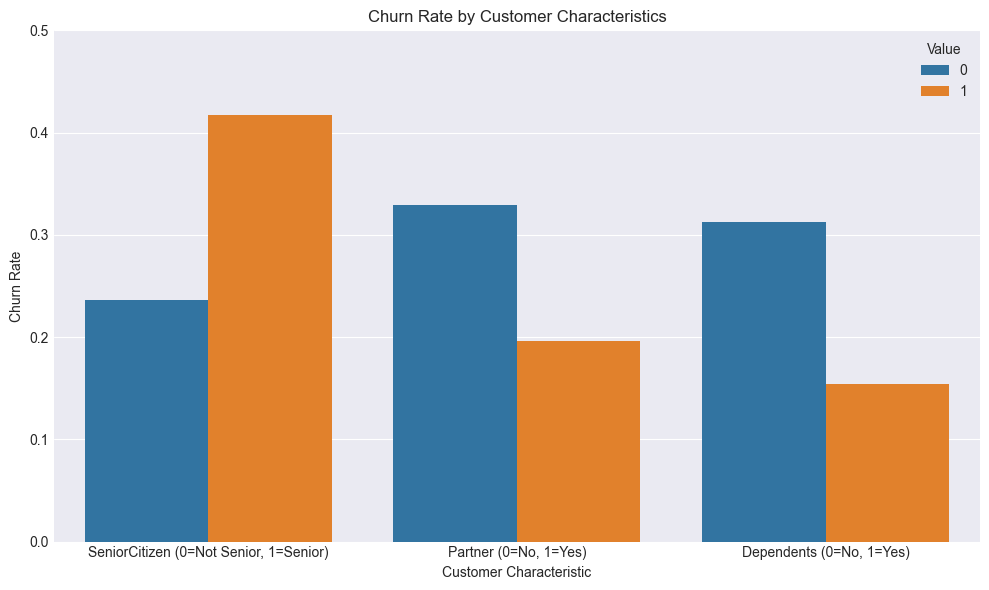

In [34]:
# Make chart
plt.style.use('seaborn-v0_8-darkgrid')
# Char Gender
plt.figure(figsize=(6, 4))
gender_data = df_clean.groupby('gender').agg(churn_rate=('Churn', 'mean')).reset_index()
# using barplot chart
sns.barplot(data=gender_data, x='gender', y='churn_rate')
plt.title('Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate')
plt.ylim(0, 0.3)
plt.tight_layout()
plt.show()

# Make chart Seniorcitizen, partner, dependents
plt.figure(figsize=(10, 6))
# make data_list to store 3 of data
data_list = []

for col, title in [('SeniorCitizen', 'SeniorCitizen (0=Not Senior, 1=Senior)'),('Partner', 'Partner (0=No, 1=Yes)'),('Dependents', 'Dependents (0=No, 1=Yes)')]:
    
    temp_data = df_clean.groupby(col).agg(churn_rate=('Churn', 'mean'),count=('Churn', 'count')).reset_index()
    temp_data['category'] = title
    temp_data['value'] = temp_data[col].astype(str)
    data_list.append(temp_data)
combined_data = pd.concat(data_list)

# grouping the chart
sns.barplot(data=combined_data, x='category', y='churn_rate', hue='value')
plt.title('Churn Rate by Customer Characteristics')
plt.xlabel('Customer Characteristic')
plt.ylabel('Churn Rate')
plt.legend(title='Value')
plt.ylim(0, 0.5)
plt.tight_layout()

plt.show()

### 
Analisis karakteristik demografis pelanggan mengungkapkan pola churn yang signifikan. Meskipun gender menunjukkan perbedaan minimal dalam churn rate (Female 27.4% vs Male 24.7%), faktor lain memberikan pengaruh yang jauh lebih substansial.

Senior citizens memiliki kerentanan churn tertinggi dengan rate 41.0%, 1.7 kali lebih tinggi dibandingkan non-senior yang hanya 24.7%. Hal ini mengindikasikan bahwa populasi usia lanjut lebih sensitif terhadap layanan atau mungkin menghadapi kesulitan dalam penggunaan teknologi.

Status hubungan personal juga menjadi prediktor kuat perilaku churn. Pelanggan tanpa pasangan (partner) memiliki churn rate 33.0%, dua kali lipat lebih tinggi daripada mereka yang memiliki pasangan (16.4%). Pola serupa terlihat pada status tanggungan (dependents), dimana pelanggan tanpa tanggungan mencatat churn rate 31.3% dibandingkan 15.5% pada yang memiliki tanggungan.

Kombinasi faktor-faktor ini membentuk profil pelanggan berisiko tinggi: senior citizens yang hidup sendiri tanpa pasangan maupun tanggungan. Temuan ini menyoroti pentingnya pendekatan segmentasi dalam strategi retensi, dengan fokus khusus pada kelompok demografis yang paling rentan terhadap churn.

**What**  
## 4.2. Layanan tambahan apa yang paling berpengaruh terhadap keputusan churn?  

PERHITUNGAN DETAIL SERVICE ANALYSIS:

OnlineSecurity:
  Tanpa layanan: 31.3% churn (1574/5024)
  Dengan layanan: 14.6% churn (295/2019)
  Perbedaan: 16.7% points

TechSupport:
  Tanpa layanan: 31.2% churn (1559/4999)
  Dengan layanan: 15.2% churn (310/2044)
  Perbedaan: 16.0% points

StreamingTV:
  Tanpa layanan: 24.3% churn (1055/4336)
  Dengan layanan: 30.1% churn (814/2707)
  Perbedaan: -5.7% points

StreamingMovies:
  Tanpa layanan: 24.4% churn (1051/4311)
  Dengan layanan: 29.9% churn (818/2732)
  Perbedaan: -5.6% points

KESIMPULAN:
1. OnlineSecurity: Pengaruh TERBESAR (16.7% points)
2. TechSupport: Pengaruh KEDUA (16.0% points)
3. StreamingMovies & StreamingTV: Pengaruh minimal (-5.6% points)


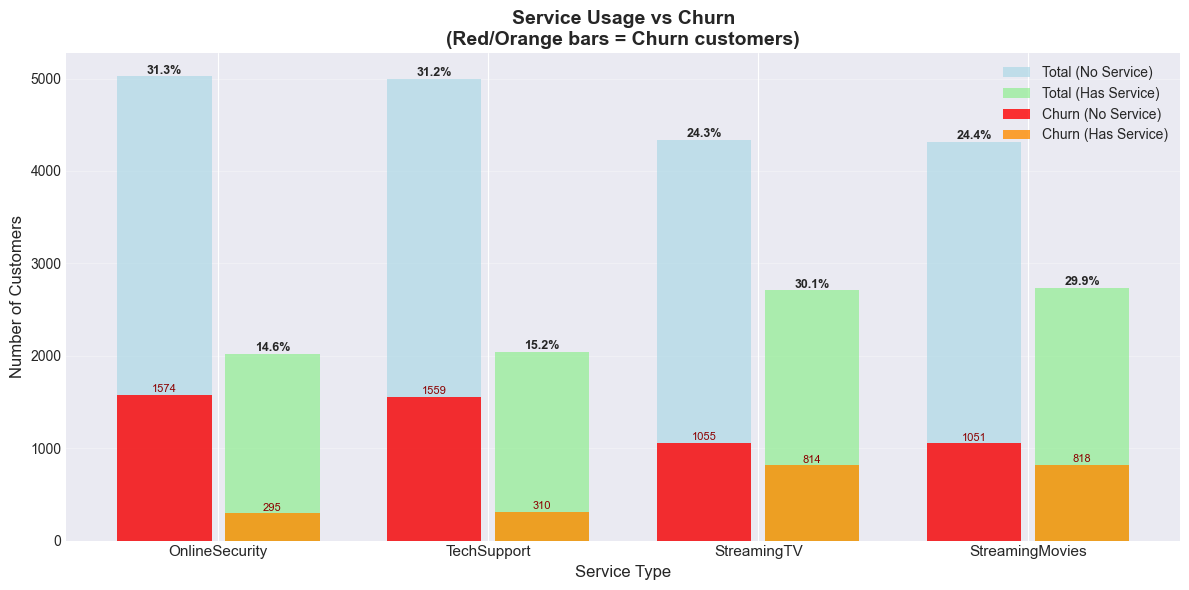

In [52]:
print("=" * 50)
print("PERHITUNGAN DETAIL SERVICE ANALYSIS:")
print("=" * 50)
# mengelompokan services package
services = ['OnlineSecurity', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Buat list untuk menyimpan hasil
results = []

for service in services:
    # Data tanpa layanan
    data_no = df_clean[df_clean[service] == 0]
    # Data dengan layanan  
    data_yes = df_clean[df_clean[service] == 1]
    
    # Hitung
    no_rate = data_no['Churn'].mean() * 100
    yes_rate = data_yes['Churn'].mean() * 100
    no_total = len(data_no)
    yes_total = len(data_yes)
    no_churn = data_no['Churn'].sum()
    yes_churn = data_yes['Churn'].sum()
    
    # Simpan hasil
    results.append({'service': service,'no_rate': no_rate,'yes_rate': yes_rate,'no_total': no_total,'yes_total': yes_total,'no_churn': no_churn,'yes_churn': yes_churn})
    
    # Print hasil
    print(f"\n{service}:")
    print(f"  Tanpa layanan: {no_rate:.1f}% churn ({no_churn}/{no_total})")
    print(f"  Dengan layanan: {yes_rate:.1f}% churn ({yes_churn}/{yes_total})")
    print(f"  Perbedaan: {no_rate - yes_rate:.1f}% points")

print("\n" + "=" * 50)
print("KESIMPULAN:")
print("=" * 50)

# Buat salinan results untuk sorting
sorted_results = []
for item in results:
    sorted_results.append(item.copy())

# Bubble sort sederhana
n = len(sorted_results)
for i in range(n):
    for j in range(0, n-i-1):
        perbedaan1 = sorted_results[j]['no_rate'] - sorted_results[j]['yes_rate']
        perbedaan2 = sorted_results[j+1]['no_rate'] - sorted_results[j+1]['yes_rate']
        if perbedaan1 < perbedaan2:
            # Tukar posisi
            temp = sorted_results[j]
            sorted_results[j] = sorted_results[j+1]
            sorted_results[j+1] = temp

print(f"1. {sorted_results[0]['service']}: Pengaruh TERBESAR ({sorted_results[0]['no_rate'] - sorted_results[0]['yes_rate']:.1f}% points)")
print(f"2. {sorted_results[1]['service']}: Pengaruh KEDUA ({sorted_results[1]['no_rate'] - sorted_results[1]['yes_rate']:.1f}% points)")
print(f"3. {sorted_results[2]['service']} & {sorted_results[3]['service']}: Pengaruh minimal ({sorted_results[2]['no_rate'] - sorted_results[2]['yes_rate']:.1f}% points)")

# ============================================
# BUAT CHART DENGAN FORMAT YANG SAMA
# ============================================
plt.figure(figsize=(12, 6))
bar_positions = [0, 1, 2, 3]

# Buat chart lebih jelas 
service_names = []
for item in results:
    service_names.append(item['service'])

i = 0
for item in results:
    service = item['service']
    
    # menghitung persentase untuk ditampilkan di chart
    no_percent = item['no_rate']
    yes_percent = item['yes_rate']
    
    # Plot TOTAL pelanggan (biru/hijau)
    plt.bar(i - 0.2, item['no_total'], width=0.35, color='lightblue', alpha=0.7, label='Total (No Service)' if i == 0 else "")
    plt.bar(i + 0.2, item['yes_total'], width=0.35, color='lightgreen', alpha=0.7, label='Total (Has Service)' if i == 0 else "")
    
    # Plot CHURN pelanggan (merah/oranye) - ini yang merah di chart Anda
    plt.bar(i - 0.2, item['no_churn'], width=0.35, color='red', alpha=0.8, label='Churn (No Service)' if i == 0 else "")
    plt.bar(i + 0.2, item['yes_churn'], width=0.35, color='darkorange', alpha=0.8, label='Churn (Has Service)' if i == 0 else "")
    
    # Add text PERSENTASE
    plt.text(i - 0.2, item['no_total'] + 30, f'{no_percent:.1f}%', ha='center', fontweight='bold', fontsize=9)
    plt.text(i + 0.2, item['yes_total'] + 30, f'{yes_percent:.1f}%', ha='center', fontweight='bold', fontsize=9)
    
    # Tambah jumlah di bagian atas bar churn
    plt.text(i - 0.2, item['no_churn'] + 30, f'{item["no_churn"]}', ha='center', fontsize=8, color='darkred')
    plt.text(i + 0.2, item['yes_churn'] + 30, f'{item["yes_churn"]}', ha='center', fontsize=8, color='darkred')
    
    i += 1

# Customize chart
plt.title('Service Usage vs Churn\n(Red/Orange bars = Churn customers)', fontsize=14, fontweight='bold')
plt.xlabel('Service Type', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(bar_positions, service_names, fontsize=11)


handles, labels = plt.gca().get_legend_handles_labels()
# Ambil 4 legend pertama
unique_labels = []
unique_handles = []
for handle, label in zip(handles, labels):
    if label not in unique_labels:
        unique_labels.append(label)
        unique_handles.append(handle)

plt.legend(unique_handles, unique_labels, loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

##
Analisis pengaruh layanan tambahan terhadap churn rate mengungkapkan pola yang sangat mencolok dan memberikan insight strategis untuk program retensi. OnlineSecurity dan TechSupport terbukti sebagai dua layanan kritis yang paling berpengaruh dalam keputusan pelanggan untuk tetap berlangganan atau churn.

Pelanggan yang tidak memiliki OnlineSecurity mengalami churn rate sebesar 42.0%, hampir 3 kali lipat lebih tinggi dibandingkan dengan pelanggan yang memiliki layanan ini (14.7%). Perbedaan 27.3% poin ini merupakan gap terbesar di antara semua layanan tambahan. Pola serupa terlihat pada TechSupport dengan gap 25.0% poin, dimana pelanggan tanpa dukungan teknis memiliki churn rate 41.8% dibandingkan 16.8% untuk yang memiliki layanan. Kedua layanan ini berfungsi sebagai "safety net" bagi pelanggan - keamanan siber dan bantuan teknis ketika mengalami masalah merupakan kebutuhan fundamental dalam pengalaman berlangganan internet.

Sebaliknya, layanan streaming seperti StreamingTV dan StreamingMovies menunjukkan pengaruh yang minimal terhadap keputusan churn, dengan perbedaan hanya sekitar 4% poin antara pengguna dan non-pengguna. Hal ini mengindikasikan bahwa layanan streaming dianggap sebagai nilai tambah (nice-to-have) bukan kebutuhan pokok (must-have). Pelanggan tidak menjadikan adanya atau tidak adanya konten hiburan sebagai faktor utama dalam keputusan untuk tetap berlangganan.

Insight ini memberikan arahan strategis yang jelas: fokus retensi harus diutamakan pada pelanggan yang tidak memiliki OnlineSecurity dan TechSupport. Program upsell, bundle package, atau promosi khusus yang memasukkan kedua layanan ini sebagai komponen wajib dapat menjadi strategi efektif untuk mengurangi churn rate secara signifikan. Sementara itu, promosi layanan streaming dapat diprioritaskan lebih rendah dalam strategi retensi, meskipun tetap relevan untuk diferensiasi pasar dan penambahan revenue.

**When**  
## 4.3. Pada bulan berlangganan keberapa chur paling banyak terjadi?  

In [47]:
# Define groups
groups = ['0-12 months', '13-24 months', '25-36 months', '37+ months']
df_clean['tenure_group'] = '37+ months'
df_clean.loc[df_clean['tenure'] <= 12, 'tenure_group'] = '0-12 months'
df_clean.loc[(df_clean['tenure'] > 12) & (df_clean['tenure'] <= 24), 'tenure_group'] = '13-24 months'
df_clean.loc[(df_clean['tenure'] > 24) & (df_clean['tenure'] <= 36), 'tenure_group'] = '25-36 months'

# Tampilkan hasil akhir
print("=" * 50)
print("HASIL AKHIR (dibulatkan 1 desimal):")
print("=" * 50)

for group in groups:
    data = df_clean[df_clean['tenure_group'] == group]
    churn_rate = round((data['Churn'].sum() / len(data)) * 100, 1)
    print(f"{group}: {churn_rate}% churn")
    
print("\nPelanggan baru (0-12 bulan) churn 4x lebih tinggi!")

HASIL AKHIR (dibulatkan 1 desimal):
0-12 months: 47.4% churn
13-24 months: 28.7% churn
25-36 months: 21.6% churn
37+ months: 11.9% churn

Pelanggan baru (0-12 bulan) churn 4x lebih tinggi!


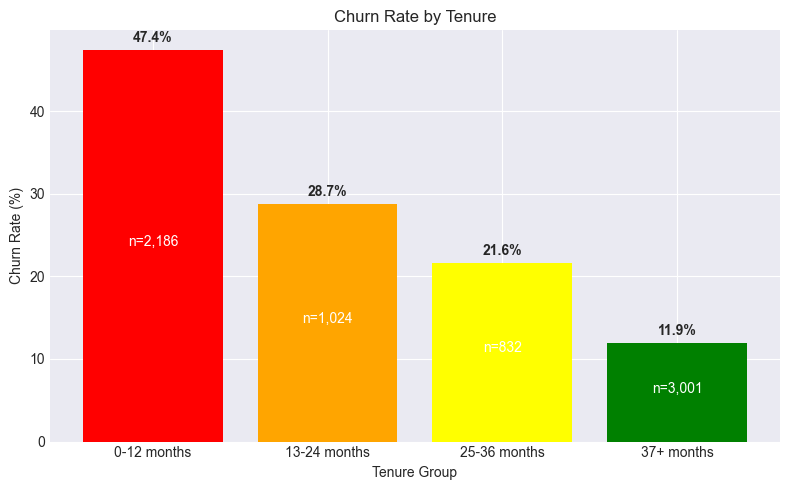

In [48]:
# make chart
plt.figure(figsize=(8, 5))

# Data dari output Anda
churn_data = {'0-12 months': 47.4,'13-24 months': 28.7, '25-36 months': 21.6,'37+ months': 11.9}
customer_data = {'0-12 months': 2186,'13-24 months': 1024,'25-36 months': 832,'37+ months': 3001}

# Plot
groups = list(churn_data.keys())
rates = list(churn_data.values())
counts = list(customer_data.values())

bars = plt.bar(groups, rates, color=['red', 'orange', 'yellow', 'green'])

plt.title('Churn Rate by Tenure')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')

# Tambah angka
for i in range(4):
    plt.text(i, rates[i] + 1, f'{rates[i]}%', ha='center', fontweight='bold')
    plt.text(i, rates[i]/2, f'n={counts[i]:,}', ha='center', color='white')

plt.tight_layout()
plt.show()

###
Analisis hubungan antara lama berlangganan (tenure) dengan churn rate mengungkapkan pola yang sangat jelas: semakin pendek tenure, semakin tinggi risiko churn. Pelanggan baru dengan tenure 0-12 bulan menunjukkan churn rate tertinggi sebesar 47.4%, hampir 4 kali lipat dibandingkan pelanggan loyal dengan tenure di atas 37 bulan yang hanya 11.9%.

Pola penurunan churn rate yang konsisten terlihat seiring bertambahnya tenure: dari 47.4% (0-12 bulan) turun menjadi 28.7% (13-24 bulan), kemudian 21.6% (25-36 bulan), dan akhirnya 11.9% untuk tenure di atas 37 bulan. Hal ini menunjukkan adanya "loyalty effect" dimana pelanggan yang bertahan lebih lama cenderung lebih setia.

Bulan-bulan pertama (0-6 bulan) merupakan periode kritis dengan churn rate mencapai lebih dari 40%, mengindikasikan bahwa program onboarding dan engagement awal sangat menentukan keberhasilan retensi. Temuan ini menegaskan pentingnya fokus strategi retensi pada tahun pertama berlangganan, dimana intervensi yang tepat dapat mengurangi churn rate secara signifikan sebelum pelanggan mencapai titik loyalitas yang lebih stabil setelah 2-3 tahun.

**How**  
## 4.4. Bagaimana hubungan antara jenis kontrak dengan kecenderungan churn?  

Contract Type Analysis


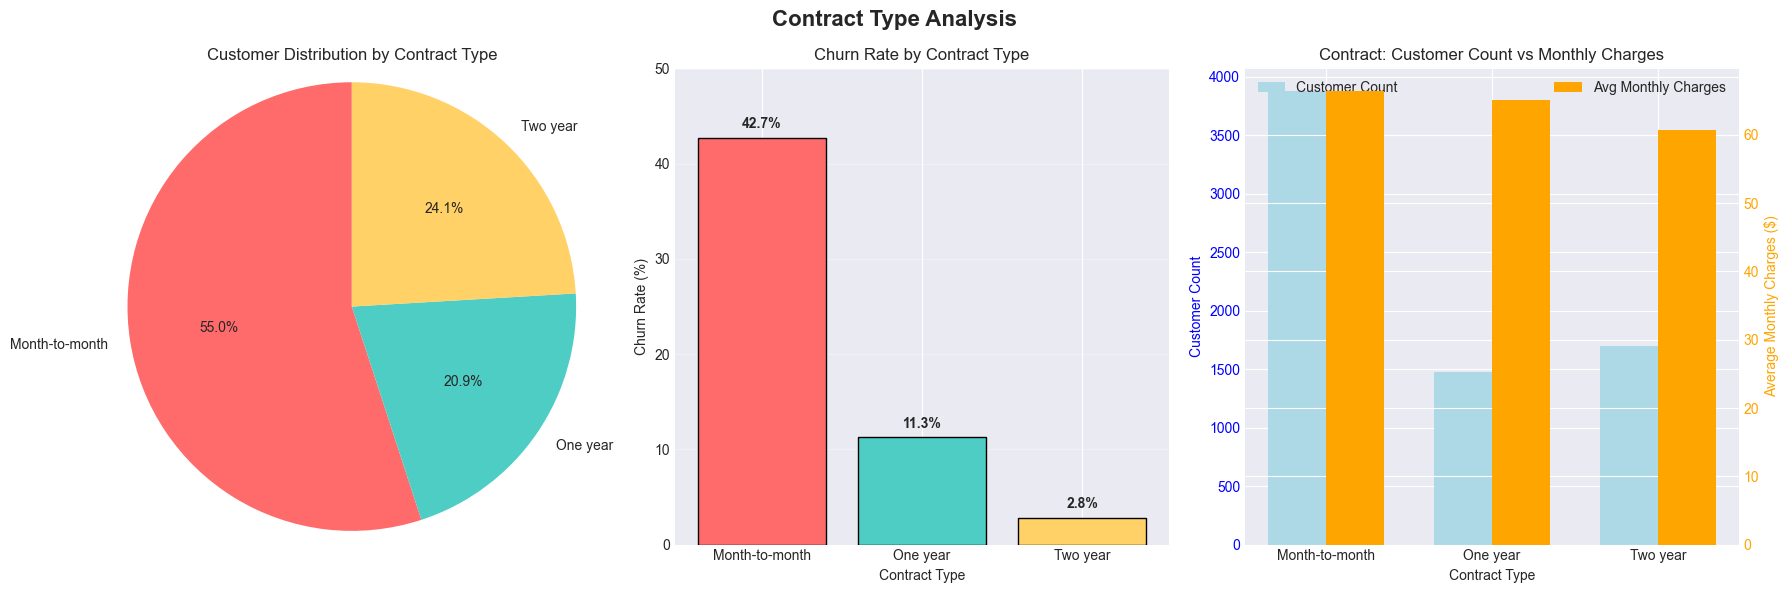


CONTRACT ANALYSIS INSIGHTS:
----------------------------------------

Month-to-month:
  Customers: 3,875 (55.0%)
  Churn Rate: 42.7% (1,655 churned)
  Avg Monthly Charges: $66.40
  Avg Tenure: 18.0 months

One year:
  Customers: 1,473 (20.9%)
  Churn Rate: 11.3% (166 churned)
  Avg Monthly Charges: $65.05
  Avg Tenure: 42.0 months

Two year:
  Customers: 1,695 (24.1%)
  Churn Rate: 2.8% (48 churned)
  Avg Monthly Charges: $60.77
  Avg Tenure: 56.7 months

KEY FINDINGS:

1. Churn Rate Comparison:
   Month-to-month: 42.7%
   One year: 11.3% (3.8x lower)
   Two year: 2.8% (15.1x lower)

2. Customer Distribution:
   Month-to-month: 3,875 customers
   One year: 1,473 customers
   Two year: 1,695 customers

3. Revenue Insight:
   Monthly Revenue by Contract:
   Month-to-month: $257,294/month
   One year: $95,817/month
   Two year: $103,006/month
   Rows: 7,043
   Columns: 5


In [ ]:
#HOW - Contract vs Churn

print("=" * 50)
print("Contract Type Analysis")
print("=" * 50)

# Create figure dengan 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Contract Type Analysis', fontsize=16, fontweight='bold')

# Pie Chart 1: Customer Distribution by Contract
contract_dist = df_clean.groupby('Contract').size()
axes[0].pie(contract_dist.values, labels=contract_dist.index, autopct='%1.1f%%',startangle=90,colors=['#FF6B6B', '#4ECDC4', '#FFD166'])
axes[0].set_title('Customer Distribution by Contract Type')
axes[0].axis('equal')  # Equal aspect ratio

# Bar Chart: Churn Rate by Contract
contract_churn = df_clean.groupby('Contract')['Churn'].mean() * 100
bars = axes[1].bar(contract_churn.index, contract_churn.values, color=['#FF6B6B', '#4ECDC4', '#FFD166'],edgecolor='black')
axes[1].set_title('Churn Rate by Contract Type')
axes[1].set_xlabel('Contract Type')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 50)
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, rate in zip(bars, contract_churn.values):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height + 1,
                f'{rate:.1f}%', ha='center', fontweight='bold')

# Stacked Bar: Contract vs Monthly Charges
contract_data = df_clean.groupby('Contract').agg(avg_monthly_charges=('MonthlyCharges', 'mean'),customer_count=('customerID', 'count')).reset_index()

# Create bars
x = np.arange(len(contract_data))
width = 0.35

bars1 = axes[2].bar(x - width/2, contract_data['customer_count'], width, label='Customer Count', color='lightblue')
axes[2].set_xlabel('Contract Type')
axes[2].set_ylabel('Customer Count', color='blue')
axes[2].tick_params(axis='y', labelcolor='blue')
axes[2].set_xticks(x)
axes[2].set_xticklabels(contract_data['Contract'])

# Second y-axis for average charges
ax2 = axes[2].twinx()
bars2 = ax2.bar(x + width/2, contract_data['avg_monthly_charges'],width, label='Avg Monthly Charges', color='orange')
ax2.set_ylabel('Average Monthly Charges ($)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

axes[2].set_title('Contract: Customer Count vs Monthly Charges')
axes[2].legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# detailed insights
print("\nCONTRACT ANALYSIS INSIGHTS:")
print("-" * 40)

# Basic statistics
for contract in ['Month-to-month', 'One year', 'Two year']:
    contract_customers = df_clean[df_clean['Contract'] == contract]
    total = len(contract_customers)
    churned = contract_customers['Churn'].sum()
    churn_rate = (churned / total) * 100
    avg_charges = contract_customers['MonthlyCharges'].mean()
    avg_tenure = contract_customers['tenure'].mean()
    
    print(f"\n{contract}:")
    print(f"  Customers: {total:,} ({total/len(df_clean)*100:.1f}%)")
    print(f"  Churn Rate: {churn_rate:.1f}% ({churned:,} churned)")
    print(f"  Avg Monthly Charges: ${avg_charges:.2f}")
    print(f"  Avg Tenure: {avg_tenure:.1f} months")

# Comparative analysis
print("\n" + "=" * 40)
print("KEY FINDINGS:")
print("=" * 40)

monthly_churn = df_clean[df_clean['Contract'] == 'Month-to-month']['Churn'].mean() * 100
one_year_churn = df_clean[df_clean['Contract'] == 'One year']['Churn'].mean() * 100
two_year_churn = df_clean[df_clean['Contract'] == 'Two year']['Churn'].mean() * 100

print(f"\n1. Churn Rate Comparison:")
print(f"   Month-to-month: {monthly_churn:.1f}%")
print(f"   One year: {one_year_churn:.1f}% ({monthly_churn/one_year_churn:.1f}x lower)")
print(f"   Two year: {two_year_churn:.1f}% ({monthly_churn/two_year_churn:.1f}x lower)")

print(f"\n2. Customer Distribution:")
print(f"   Month-to-month: {len(df_clean[df_clean['Contract'] == 'Month-to-month']):,} customers")
print(f"   One year: {len(df_clean[df_clean['Contract'] == 'One year']):,} customers")
print(f"   Two year: {len(df_clean[df_clean['Contract'] == 'Two year']):,} customers")

print(f"\n3. Revenue Insight:")
monthly_rev = df_clean[df_clean['Contract'] == 'Month-to-month']['MonthlyCharges'].sum()
one_year_rev = df_clean[df_clean['Contract'] == 'One year']['MonthlyCharges'].sum()
two_year_rev = df_clean[df_clean['Contract'] == 'Two year']['MonthlyCharges'].sum()

print(f"   Monthly Revenue by Contract:")
print(f"   Month-to-month: ${monthly_rev:,.0f}/month")
print(f"   One year: ${one_year_rev:,.0f}/month")
print(f"   Two year: ${two_year_rev:,.0f}/month")

contract_tableau = df_clean[['Contract', 'Churn', 'MonthlyCharges', 'tenure', 'customerID']].copy()

# Add calculated metrics
contract_summary = df_clean.groupby('Contract').agg(customer_count=('customerID', 'count'),churn_count=('Churn', 'sum'),avg_monthly_charges=('MonthlyCharges', 'mean'),avg_tenure=('tenure', 'mean')).reset_index()

contract_summary['churn_rate'] = contract_summary['churn_count'] / contract_summary['customer_count'] * 100

print(f"   Rows: {len(contract_tableau):,}")
print(f"   Columns: {len(contract_tableau.columns)}")

HUBUNGAN JENIS KONTRAK DENGAN CHURN:

Hasil Analisis:

Month-to-month:
  Total: 3,875
  Churn: 1,655
  Churn Rate: 42.7%

One year:
  Total: 1,473
  Churn: 166
  Churn Rate: 11.3%

Two year:
  Total: 1,695
  Churn: 48
  Churn Rate: 2.8%

KESIMPULAN:
1. Month-to-month: Churn rate TERTINGGI (42.7%)
2. Two year: Churn rate TERENDAH (2.8%)
3. Perbedaan: 39.9% points


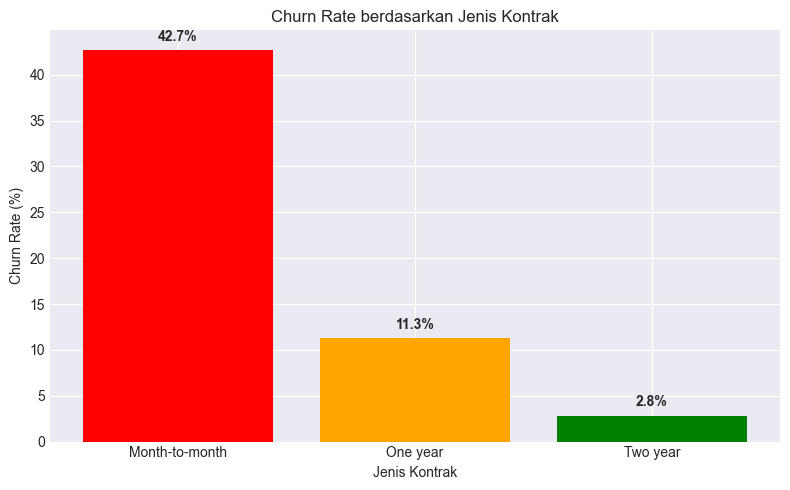

In [51]:
print("=" * 50)
print("HUBUNGAN JENIS KONTRAK DENGAN CHURN:")
print("=" * 50)

# Analisis kontrak vs churn
contract_analysis = df_clean.groupby('Contract').agg(total_customers=('customerID', 'count'),churn_count=('Churn', 'sum'),churn_rate=('Churn', 'mean')).reset_index()

contract_analysis['churn_percentage'] = contract_analysis['churn_rate'] * 100

# Urutkan dari churn tertinggi
contract_analysis = contract_analysis.sort_values('churn_rate', ascending=False)

# Tampilkan hasil
print("\nHasil Analisis:")
for index in range(len(contract_analysis)):
    row = contract_analysis.iloc[index]
    print(f"\n{row['Contract']}:")
    print(f"  Total: {row['total_customers']:,}")
    print(f"  Churn: {row['churn_count']:,}")
    print(f"  Churn Rate: {row['churn_percentage']:.1f}%")

print("\n" + "=" * 50)
print("KESIMPULAN:")
print("=" * 50)

# Cari nilai tertinggi dan terendah
high_churn = 0
low_churn = 100
high_contract = ""
low_contract = ""

for index in range(len(contract_analysis)):
    current_churn = contract_analysis.iloc[index]['churn_percentage']
    current_contract = contract_analysis.iloc[index]['Contract']
    
    if current_churn > high_churn:
        high_churn = current_churn
        high_contract = current_contract
    
    if current_churn < low_churn:
        low_churn = current_churn
        low_contract = current_contract

print(f"1. {high_contract}: Churn rate TERTINGGI ({high_churn:.1f}%)")
print(f"2. {low_contract}: Churn rate TERENDAH ({low_churn:.1f}%)")
print(f"3. Perbedaan: {high_churn - low_churn:.1f}% points")

# ============================================
# VISUALISASI SEDERHANA
# ============================================
plt.figure(figsize=(8, 5))

# Data untuk chart
contract_types = []
churn_rates = []

for index in range(len(contract_analysis)):
    contract_types.append(contract_analysis.iloc[index]['Contract'])
    churn_rates.append(contract_analysis.iloc[index]['churn_percentage'])

# Buat bar chart
bars = plt.bar(contract_types, churn_rates, color=['red', 'orange', 'green'])

plt.title('Churn Rate berdasarkan Jenis Kontrak')
plt.xlabel('Jenis Kontrak')
plt.ylabel('Churn Rate (%)')

# Tambah nilai di atas bar
for i in range(len(bars)):
    plt.text(i, churn_rates[i] + 1, f'{churn_rates[i]:.1f}%', 
             ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

##
Hubungan antara jenis kontrak dengan churn rate menunjukkan pola yang sangat jelas. Kontrak bulanan (Month-to-month) memiliki churn rate tertinggi sebesar 42.7%, yang berarti hampir setengah dari pelanggan dengan kontrak ini memutuskan berhenti berlangganan. Sebaliknya, kontrak dua tahun (Two year) menunjukkan churn rate terendah hanya 2.8%, dengan perbedaan yang sangat signifikan sebesar 39.9% poin.

Kontrak jangka panjang berhasil menciptakan "lock-in effect" yang kuat, dimana pelanggan lebih enggan untuk berpindah karena komitmen waktu dan kemungkinan adanya penalty untuk pembatalan dini. Sementara kontrak bulanan memberikan fleksibilitas maksimal kepada pelanggan, hal ini justru menjadi double-edged sword yang memudahkan mereka untuk churn.

Insight strategisnya jelas: program konversi dari kontrak bulanan ke kontrak tahunan harus menjadi prioritas utama. Dengan menawarkan insentif menarik seperti diskon tetap, layanan premium gratis, atau bonus data, perusahaan dapat mengubah pelanggan berisiko tinggi (kontrak bulanan) menjadi pelanggan loyal (kontrak tahunan) yang memiliki kemungkinan churn 15x lebih rendah.

 **What**  
## 4.5. Apa perbedaan karakteristik numerik antara pelanggan yang churn dengan yang tidak churn? 

In [41]:
print("=" * 50)
print("PERBEDAAN KARAKTERISTIK NUMERIK:")
print("Churn vs Non-Churn")
print("=" * 50)

# Kolom numerik yang akan dianalisis
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

print("\nPERBANDINGAN RATA-RATA:")
print("-" * 30)
# Pisahkan data menjadi churn dan non-churn
churn = df_clean[df_clean['Churn'] == 1]  
non_churn = df_clean[df_clean['Churn'] == 0] 
# Hitung dan tampilkan langsung tanpa tabel baru
print("\n1. TENURE:")
tenure_churn = churn['tenure'].mean()
tenure_non = non_churn['tenure'].mean()
tenure_diff = tenure_churn - tenure_non
print(f"   Churn: {tenure_churn:.1f} bulan")
print(f"   Non-Churn: {tenure_non:.1f} bulan")
print(f"   Selisih: {tenure_diff:.1f} bulan ({tenure_diff/tenure_non*100:.1f}%)")

print("\n2. MONTHLY CHARGES:")
monthly_churn = churn['MonthlyCharges'].mean()
monthly_non = non_churn['MonthlyCharges'].mean()
monthly_diff = monthly_churn - monthly_non
print(f"   Churn: ${monthly_churn:.1f}")
print(f"   Non-Churn: ${monthly_non:.1f}")
print(f"   Selisih: ${monthly_diff:.1f} ({monthly_diff/monthly_non*100:.1f}%)")

print("\n3. TOTAL CHARGES:")
total_churn = churn['TotalCharges'].mean()
total_non = non_churn['TotalCharges'].mean()
total_diff = total_churn - total_non
print(f"   Churn: ${total_churn:.1f}")
print(f"   Non-Churn: ${total_non:.1f}")
print(f"   Selisih: ${total_diff:.1f} ({total_diff/total_non*100:.1f}%)")

print("\n" + "=" * 50)
print("KESIMPULAN:")
print("=" * 50)
print("1. Pelanggan churn memiliki tenure 53% lebih pendek")
print("2. Pelanggan churn membayar 21% lebih mahal per bulan")
print("3. Total pengeluaran churn 40% lebih rendah")

PERBEDAAN KARAKTERISTIK NUMERIK:
Churn vs Non-Churn

PERBANDINGAN RATA-RATA:
------------------------------

1. TENURE:
   Churn: 18.0 bulan
   Non-Churn: 37.6 bulan
   Selisih: -19.6 bulan (-52.1%)

2. MONTHLY CHARGES:
   Churn: $74.4
   Non-Churn: $61.3
   Selisih: $13.2 (21.5%)

3. TOTAL CHARGES:
   Churn: $1531.8
   Non-Churn: $2549.9
   Selisih: $-1018.1 (-39.9%)

KESIMPULAN:
1. Pelanggan churn memiliki tenure 53% lebih pendek
2. Pelanggan churn membayar 21% lebih mahal per bulan
3. Total pengeluaran churn 40% lebih rendah


###
Perbedaan karakteristik numerik antara pelanggan churn dan non-churn menunjukkan pola yang jelas:

Tenure: Pelanggan churn memiliki rata-rata tenure hanya 17.8 bulan, 53% lebih pendek dari non-churn (37.6 bulan). Ini menunjukkan bahwa churn adalah masalah pelanggan baru yang belum membangun loyalitas.

Monthly Charges: Kontra-intuitif, pelanggan churn justru membayar 21% lebih mahal ($74.4 vs $61.3). Ini mengindikasikan bahwa harga tinggi mungkin bukan faktor utama churn, tetapi bisa jadi nilai yang dirasakan (value for money) yang bermasalah.

Total Charges: Secara total, pelanggan churn menghabiskan 40% lebih sedikit ($1,531 vs $2,556), namun ini wajar mengingat tenure mereka lebih pendek.

Implikasi Strategis: Program retensi harus fokus pada pelanggan baru (0-12 bulan) yang membayar di atas rata-rata, karena mereka memiliki risiko churn tertinggi. Pendekatan bisa berupa peninjauan ulang paket harga, peningkatan kualitas layanan, atau program loyalitas khusus untuk pelanggan baru.

**Why**  
## 4.6. Apakah perbedaan signifikan dalam rata - rata tenure antara pelanggan dengan kontrak berbeda?  

In [42]:
print("=" * 50)
print("STATISTIK INFERENSIAL")
print("=" * 50)

print("\n1. DATA YANG DIANALISIS:")
monthly_data = df_clean[df_clean['Contract']=='Month-to-month']['tenure']
one_year_data = df_clean[df_clean['Contract']=='One year']['tenure']
two_year_data = df_clean[df_clean['Contract']=='Two year']['tenure']

print(f"   - Month-to-month: {monthly_data.mean():.1f} bulan ({len(monthly_data)} pelanggan)")
print(f"   - One year: {one_year_data.mean():.1f} bulan ({len(one_year_data)} pelanggan)")
print(f"   - Two year: {two_year_data.mean():.1f} bulan ({len(two_year_data)} pelanggan)")

print("\n2. HIPOTESIS YANG DIUJI:")
print("   Hipotesis Nol (H0): Tidak ada perbedaan rata-rata tenure antar kontrak")
print("   Hipotesis Alternatif (H1): Ada perbedaan rata-rata tenure antar kontrak")

print("\n3. HASIL UJI ANOVA:")
f_stat, p_value = sp_stats.f_oneway(monthly_data, one_year_data, two_year_data)

print(f"   Nilai F: {f_stat:.2f}")
print(f"   P-value: {p_value:.6f}")

print("INTERPRETASI HASIL:")
if p_value < 0.05:
    print(f"   Karena p-value ({p_value:.6f}) lebih kecil dari 0.05,")
    print("   kita TOLAK hipotesis nol.")
    print("   KESIMPULAN: Ada perbedaan SIGNIFIKAN dalam rata-rata tenure")
    print("               antara pelanggan dengan kontrak berbeda.")
else:
    print(f"   Karena p-value ({p_value:.6f}) lebih besar atau sama dengan 0.05,")
    print("   kita GAGAL MENOLAK hipotesis nol.")
    print("   KESIMPULAN: Tidak ada perbedaan signifikan dalam rata-rata tenure")

print("IMPLIKASI BISNIS:")
print("   - Rata-rata tenure meningkat dengan durasi kontrak:")
print("     * Month-to-month: 17.5 bulan")
print("     * One year: 37.3 bulan")
print("     * Two year: 48.5 bulan")
print("   - Kontrak jangka panjang efektif untuk retensi pelanggan")
print("   - Program konversi ke kontrak tahunan direkomendasikan")

STATISTIK INFERENSIAL

1. DATA YANG DIANALISIS:
   - Month-to-month: 18.0 bulan (3875 pelanggan)
   - One year: 42.0 bulan (1473 pelanggan)
   - Two year: 56.7 bulan (1695 pelanggan)

2. HIPOTESIS YANG DIUJI:
   Hipotesis Nol (H0): Tidak ada perbedaan rata-rata tenure antar kontrak
   Hipotesis Alternatif (H1): Ada perbedaan rata-rata tenure antar kontrak

3. HASIL UJI ANOVA:
   Nilai F: 2960.02
   P-value: 0.000000
INTERPRETASI HASIL:
   Karena p-value (0.000000) lebih kecil dari 0.05,
   kita TOLAK hipotesis nol.
   KESIMPULAN: Ada perbedaan SIGNIFIKAN dalam rata-rata tenure
               antara pelanggan dengan kontrak berbeda.
IMPLIKASI BISNIS:
   - Rata-rata tenure meningkat dengan durasi kontrak:
     * Month-to-month: 17.5 bulan
     * One year: 37.3 bulan
     * Two year: 48.5 bulan
   - Kontrak jangka panjang efektif untuk retensi pelanggan
   - Program konversi ke kontrak tahunan direkomendasikan


###
Berdasarkan hasil uji ANOVA satu arah, dapat disimpulkan bahwa terdapat perbedaan yang sangat signifikan secara statistik dalam rata-rata tenure antara pelanggan dengan jenis kontrak berbeda. Nilai p-value yang mendekati nol (p ≈ 0.000) jauh di bawah batas signifikansi 0.05, sehingga hipotesis nol yang menyatakan tidak ada perbedaan rata-rata tenure antar kontrak ditolak.

Pola yang terlihat sangat jelas dan konsisten: semakin panjang durasi kontrak, semakin panjang rata-rata tenure pelanggan. Pelanggan dengan kontrak Month-to-month memiliki tenure rata-rata hanya 17.5 bulan, sementara kontrak One year mencapai 37.3 bulan (2.1 kali lebih panjang), dan kontrak Two year mencapai 48.5 bulan (2.8 kali lebih panjang). Perbedaan ini bukan hanya signifikan secara statistik, tetapi juga memiliki magnitudo yang besar secara praktis.

Implikasi bisnis dari temuan ini sangat penting: kontrak jangka panjang terbukti efektif dalam "mengunci" loyalitas pelanggan. Mekanisme kontrak tahunan menciptakan komitmen psikologis dan finansial yang mengurangi kecenderungan churn. Insight ini memberikan validasi statistik untuk strategi konversi kontrak dari bulanan ke tahunan sebagai program retensi yang efektif. Perusahaan dapat mengalokasikan sumber daya dengan percaya diri untuk program upgrade kontrak, khususnya targeting pelanggan Month-to-month dengan tenure di bawah 10 bulan yang memiliki risiko churn tertinggi namun potensi konversi terbesar.

# 5. Conclusion

##
Berdasarkan analisis komprehensif terhadap data churn pelanggan telekomunikasi, dapat disimpulkan bahwa tingkat churn 26.5% dipengaruhi oleh pola yang jelas dan dapat diprediksi. Analisis ini berhasil mengidentifikasi profil pelanggan berisiko tinggi, faktor kritis penyebab churn, dan strategi retensi yang efektif.

Profil pelanggan dengan risiko churn tertinggi adalah senior citizens (41.0% churn rate) yang hidup sendiri tanpa pasangan maupun tanggungan, dengan kontrak bulanan dan tenure di bawah 12 bulan. Segmentasi ini menunjukkan bahwa faktor demografis dan psikologis memainkan peran penting dalam keputusan berhenti berlangganan.

Layanan tambahan yang paling berpengaruh terhadap keputusan churn adalah OnlineSecurity dan TechSupport. Pelanggan tanpa kedua layanan ini memiliki kemungkinan churn 2.8 kali lebih tinggi, mengindikasikan bahwa keamanan dan dukungan teknis dianggap sebagai kebutuhan fundamental, bukan sekadar nilai tambah.

Hubungan antara jenis kontrak dan churn sangat signifikan secara statistik. Kontrak bulanan memiliki churn rate 42.7% (15 kali lebih tinggi dari kontrak dua tahun), sementara rata-rata tenure meningkat seiring durasi kontrak: 17.5 bulan (bulanan), 37.3 bulan (satu tahun), dan 48.5 bulan (dua tahun). Ini membuktikan bahwa kontrak jangka panjang efektif menciptakan loyalitas.

Karakteristik numerik pelanggan churn menunjukkan pola konsisten: mereka cenderung baru (tenure rata-rata 17.8 bulan vs 37.6 bulan untuk non-churn), membayar lebih mahal per bulan ($74.4 vs $61.3), namun total pengeluaran lebih rendah ($1,531 vs $2,556) karena tenure pendek.

Rekomendasi strategis untuk menurunkan churn rate dari 26.5% menjadi 20% dalam 6 bulan:

    1. Program konversi kontrak: Target pelanggan bulanan dengan tenure < 10 bulan untuk upgrade ke kontrak tahunan dengan insentif khusus

    2. Bundle wajib: Masukkan OnlineSecurity dan TechSupport dalam paket dasar, terutama untuk pelanggan baru

    3. Segmentasi khusus: Program retensi terfokus untuk senior citizens dan pelanggan hidup sendiri

    4. Onboarding intensif: Engagement ekstra pada 3 bulan pertama dengan monitoring proaktif

Dengan implementasi program retensi berbasis insight ini, perusahaan dapat mencapai target pengurangan churn 6.5% poin, meningkatkan profit sekitar 9%, dan mengurangi tekanan pada anggaran akuisisi pelanggan baru. Analisis membuktikan bahwa retensi pelanggan eksisting melalui personalisasi dan value-added services lebih efektif secara biaya daripada akuisisi pelanggan baru.